<a href="https://colab.research.google.com/github/lakshuu-jay/Projects/blob/main/ExamplesOfRecomendationEngine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

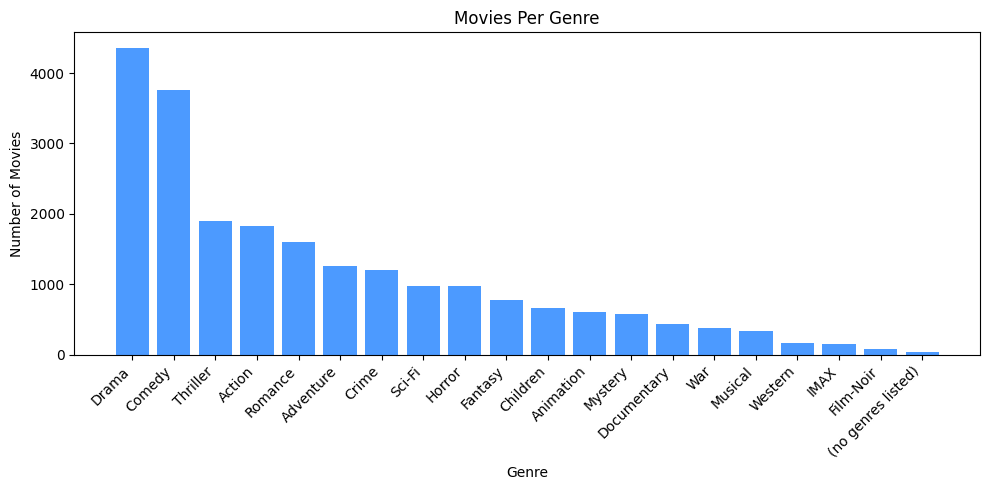

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ratings_df = pd.read_csv("ratings.csv")
ratings_df.head()

movies_df = pd.read_csv("movies.csv")
movies_df.head()

movies_df['year'] = movies_df.title.str.extract(r'(\(\d\d\d\d\))', expand=True)
movies_df['year'] = movies_df.year.str.extract(r'(\d\d\d\d)', expand=True)

movies_df['title'] = movies_df.title.str.replace(r'(\(\d\d\d\d\))', '', regex=True)
movies_df['title'] = movies_df['title'].apply(lambda x: x.strip())

movies_df.head()

movies_df['genres'] = movies_df.genres.str.split('|')

movies_copy = movies_df.copy()
for index, row in movies_df.iterrows():
    for genre in row['genres']:
        movies_copy.at[index, genre] = 1

movies_copy = movies_copy.fillna(0)
movies_copy.head()

ratings_df = ratings_df.drop(['timestamp'], axis=1)
ratings_df.head()

genre_columns = movies_copy.drop(['movieId', 'title', 'genres', 'year'], axis=1)
genre_counts = genre_columns.sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(genre_counts.index, genre_counts.values, color='#4C9AFF')
plt.title('Movies Per Genre')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
